In [2]:
# imports
import pandas as pd
import seaborn as sns
import warnings
import pickle
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ignore all warnings
warnings.filterwarnings('ignore')

# load the dataset
data = load_breast_cancer(as_frame=True)
df = data.frame

# Exploratory Data Analysis

---

In [3]:
# see first few rows of the dataset
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# check the overall shape the dataset
df.shape

(569, 31)

In [ ]:
# check data types
# df.info()
# df.describe()

In [5]:
# check for missing values
print("Missing values per feature:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per feature:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Total missing values: 0


No missing values were found across all 30 features and 569 samples. The dataset is complete and ready for modeling without any imputation needed.

In [5]:
# display the distribution of the target variable with actual class names
print("--- Target Distribution ---")
for class_id, count in df['target'].value_counts().items():
    class_name = data.target_names[class_id]
    print(f"Class {class_id} ({class_name}): {count} cases")

--- Target Distribution ---
Class 1 (benign): 357 cases
Class 0 (malignant): 212 cases


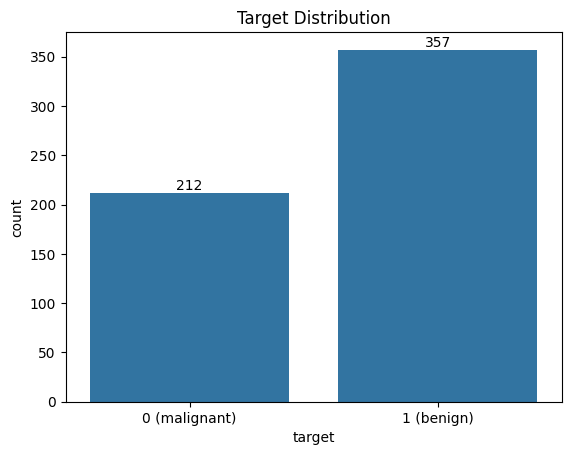

In [6]:
# visualize the distribution of the target variable
ax = sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.xticks(ticks=[0, 1], labels=['0 (malignant)', '1 (benign)'])
ax.bar_label(ax.containers[0])
plt.show()

The dataset contains more benign cases (357) than malignant cases (212). The class distribution is slightly imbalanced, but not severe enough to be a major concern. We will however use stratified splitting when dividing the data to make sure both classes are proportionally represented in the training and test sets.

In clinical settings, missing a malignant tumor is far more dangerous than a false alarm. A false negative could delay treatment and worsen patient outcomes. Because of this, we will prioritize recall as our primary evaluation metric throughout model training and hyperparameter tuning, since it directly measures how well each model catches true malignant cases.

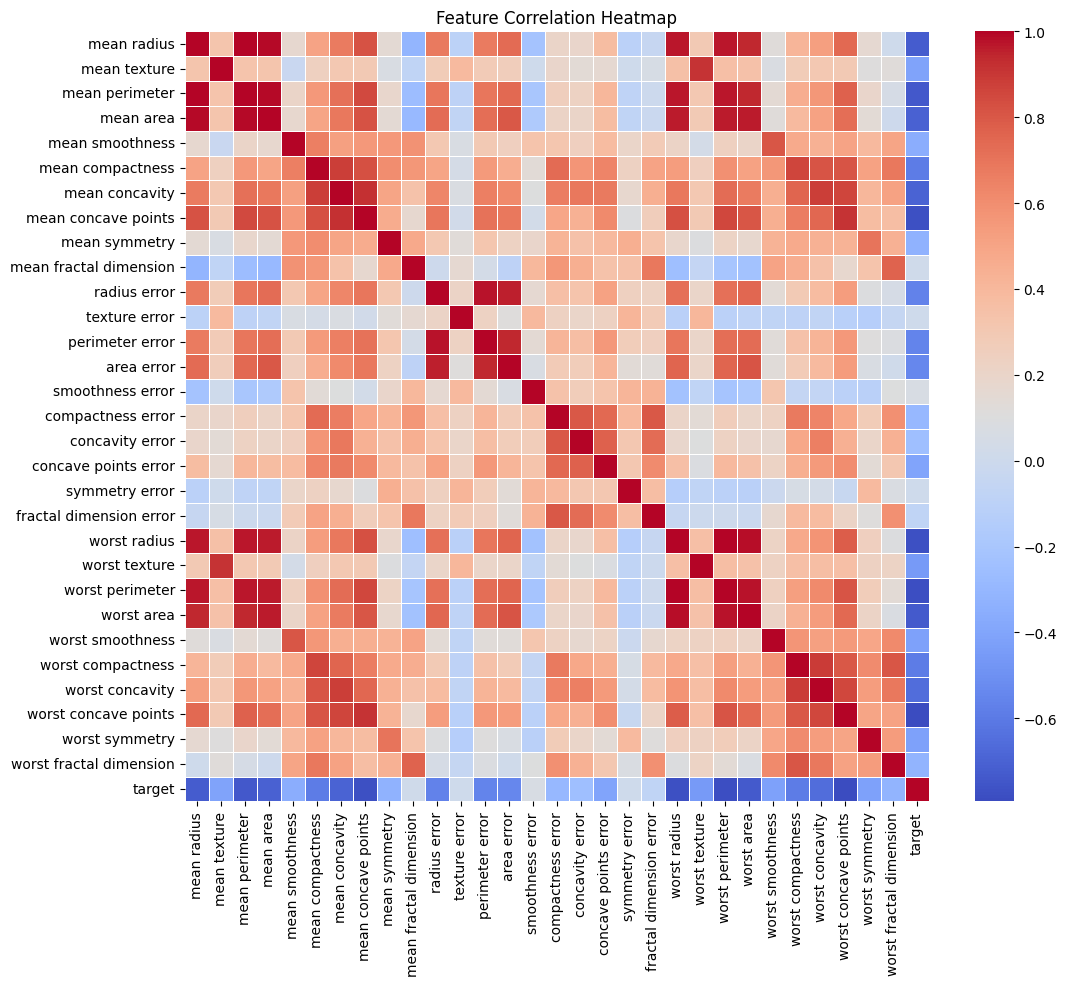

In [7]:
# plot the correlation heatmap of features
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

Looking at the heatmap, the size-related features like worst radius, worst perimeter, and worst area show the strongest negative correlation with the target variable. Since target=0 represents malignant tumors, this tells us that malignant tumors tend to have larger measurements across these features, which lines up with what we would expect clinically.

We can also see that many of these size-related features are highly correlated with each other. For example, radius, perimeter, and area are all essentially measuring the same thing in different ways. This multicollinearity is worth keeping in mind, though it matters more for some models than others.

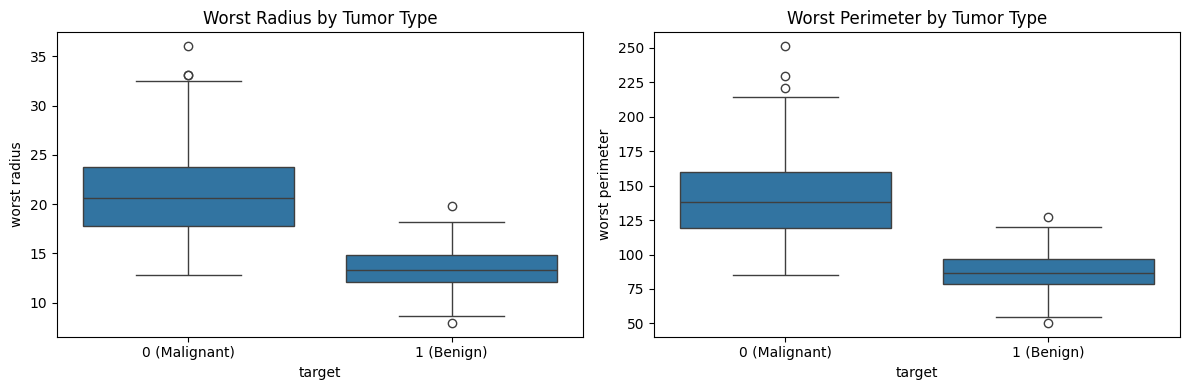

In [8]:
# plot boxplot of worst radius and worst perimeter by target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='target', y='worst radius', data=df, ax=axes[0])
axes[0].set_title("Worst Radius by Tumor Type")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 (Malignant)', '1 (Benign)'])

sns.boxplot(x='target', y='worst perimeter', data=df, ax=axes[1])
axes[1].set_title("Worst Perimeter by Tumor Type")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['0 (Malignant)', '1 (Benign)'])

plt.tight_layout()
plt.show()

As expected, malignant tumors have noticeably larger worst radius and worst perimeter values compared to benign tumors. The separation between the two classes is pretty clear, which suggests these features will be useful for classification. This also reinforces what we saw in the correlation heatmap.

# Train Models

---

In [9]:
# split the data into features and target variable
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (455, 30)
Testing set shape: (114, 30)


## Logistic Regression

In [10]:
# Logistic Regression
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        solver='liblinear',
        random_state=42
    ))
])

log_reg_param_grid = {
    'classifier__penalty' : ['l1', 'l2'],
    'classifier__C' : [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

log_reg_grid_search = GridSearchCV(
    log_reg_pipeline,
    log_reg_param_grid,
    cv=5,
    scoring='recall_macro'
)

log_reg_grid_search.fit(X_train, y_train)

print(f"_____________________ Logistic Regression Best Hyperparameters _____________________")
print(f"Best Penalty: {log_reg_grid_search.best_params_['classifier__penalty']}")
print(f"Best C: {log_reg_grid_search.best_params_['classifier__C']}")

print(f"_____________________ Logistic Regression Model Preformance _____________________")
log_reg_y_pred = log_reg_grid_search.predict(X_test)
print(classification_report(y_test, log_reg_y_pred))
print(f"Best CV Recall Score (from GridSearch): {log_reg_grid_search.best_score_:.4f}")

_____________________ Logistic Regression Best Hyperparameters _____________________
Best Penalty: l2
Best C: 0.1
_____________________ Logistic Regression Model Preformance _____________________
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

Best CV Recall Score (from GridSearch): 0.9748


Logistic Regression achieved 96% accuracy with a malignant recall of 0.98, meaning it correctly identified 41 out of 42 malignant cases. The best cross-validation recall of 0.9748 suggests the model generalizes well across different data splits.

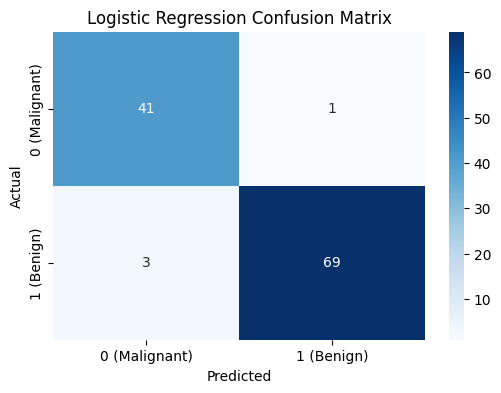

In [11]:
# Logistic Regression Confusion Matrix 
cm = confusion_matrix(y_test, log_reg_y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['0 (Malignant)', '1 (Benign)'], 
            yticklabels=['0 (Malignant)', '1 (Benign)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Only 1 malignant case was misclassified as benign, and 3 benign cases were flagged as malignant. For a clinical screening tool, keeping false negatives this low is the priority.

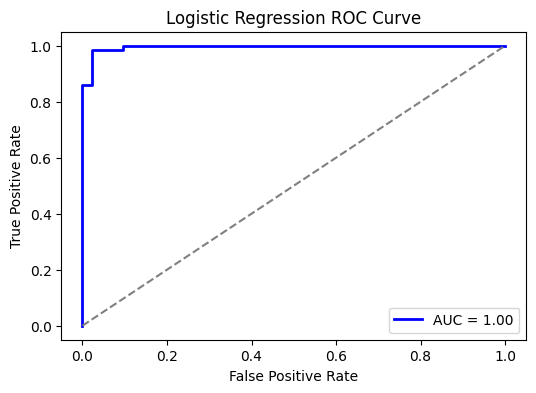

In [12]:
# Logistic Regression ROC Curve

# get the predicted probabilities for the test set
log_reg_y_prob = log_reg_grid_search.predict_proba(X_test)[:, 1]

# calculate False Positive Rate, True Positive Rate, and AUC
fpr, tpr, _ = roc_curve(y_test, log_reg_y_prob)
roc_auc = auc(fpr, tpr)

# plot the curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # The random guessing line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")
plt.show()

The AUC of 1.00 indicates near perfect class separability for logistic regression.

## Random Forest

In [13]:
# Random Forests
random_forest_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ))
])

random_forest_param_grid = {
    'classifier__n_estimators' : [50, 100, 200],
    'classifier__criterion'  : ['gini', 'entropy', 'log_loss'],
    'classifier__max_depth' : [3, 5, None],
    'classifier__min_samples_split' : [2, 5],
    'classifier__min_samples_leaf' : [1, 2]
}

random_forest_grid_search = GridSearchCV(
    random_forest_pipeline,
    random_forest_param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)

random_forest_grid_search.fit(X_train, y_train)

print(f"_____________________ Random Forest Best Hyperparameters _____________________")
print(f"Best n Estimators: {random_forest_grid_search.best_params_['classifier__n_estimators']}")
print(f"Best Criterion: {random_forest_grid_search.best_params_['classifier__criterion']}")
print(f"Max Depth: {random_forest_grid_search.best_params_['classifier__max_depth']}")
print(f"Best Min Samples Split: {random_forest_grid_search.best_params_['classifier__min_samples_split']}")
print(f"Best Min Samples Leaf: {random_forest_grid_search.best_params_['classifier__min_samples_leaf']}")


print(f"_____________________ Random Forest Model Preformance _____________________")
rf_y_pred = random_forest_grid_search.predict(X_test)
print(classification_report(y_test, rf_y_pred))
print(f"Best CV Recall Score (from GridSearch): {random_forest_grid_search.best_score_:.4f}")

_____________________ Random Forest Best Hyperparameters _____________________
Best n Estimators: 50
Best Criterion: entropy
Max Depth: None
Best Min Samples Split: 2
Best Min Samples Leaf: 1
_____________________ Random Forest Model Preformance _____________________
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Best CV Recall Score (from GridSearch): 0.9607


Random Forest achieved 96% accuracy with a malignant recall of 0.93, correctly identifying 39 out of 42 malignant cases. The CV recall of 0.9607 is the lowest of the four models, though still strong overall.

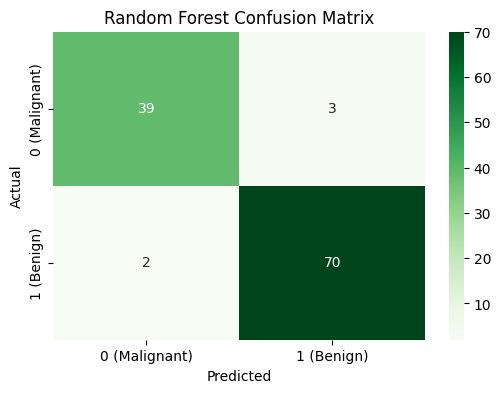

In [14]:
# Random Forest Confusion Matrix 
rf_cm = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['0 (Malignant)', '1 (Benign)'], 
            yticklabels=['0 (Malignant)', '1 (Benign)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

3 malignant cases were missed and 2 benign cases were incorrectly flagged. Compared to logistic regression, random forest produced more false negatives which is the more concerning error in a clinical context.

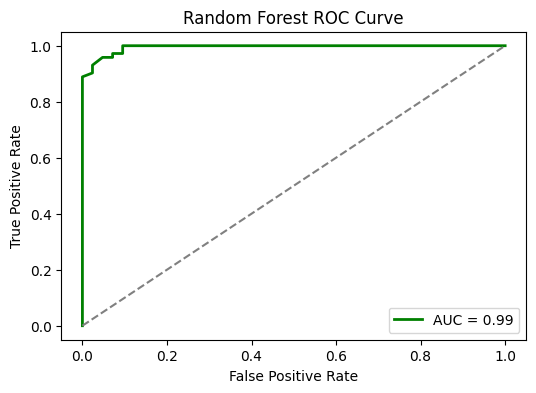

In [15]:
# Random Forest ROC Curve

# get probabilities for the positive class (class 1)
rf_y_prob = random_forest_grid_search.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_y_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f"AUC = {roc_auc_rf:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend(loc="lower right")
plt.show()

An AUC of 0.99 shows excellent class separability, just slightly below logistic regression.

## Gradient Boosting

In [16]:
# Gradient Boosting
grad_boost_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(
        random_state=42
    ))
])

grad_boost_param_grid = {
    'classifier__loss' : ['log_loss', 'exponential'],
    'classifier__learning_rate' : [0.1, 0.5, 1, 5, 10],
    'classifier__n_estimators' : [50, 100, 200],
    'classifier__criterion' : ['friedman_mse', 'squared_error'],
    'classifier__max_depth' : [3, 5],
    'classifier__min_samples_split' : [2, 5],
    'classifier__min_samples_leaf' : [1, 2]
}

grad_boost_grid_search = GridSearchCV(
    grad_boost_pipeline,
    grad_boost_param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)

grad_boost_grid_search.fit(X_train, y_train)

print(f"_____________________ Gradient Boosting Best Hyperparameters _____________________")
print(f"Best Loss: {grad_boost_grid_search.best_params_['classifier__loss']}")
print(f"Best Learning Rate: {grad_boost_grid_search.best_params_['classifier__learning_rate']}")
print(f"Best n Estimators: {grad_boost_grid_search.best_params_['classifier__n_estimators']}")
print(f"Best Criterion: {grad_boost_grid_search.best_params_['classifier__criterion']}")
print(f"Max Depth: {grad_boost_grid_search.best_params_['classifier__max_depth']}")
print(f"Best Min Samples Split: {grad_boost_grid_search.best_params_['classifier__min_samples_split']}")
print(f"Best Min Samples Leaf: {grad_boost_grid_search.best_params_['classifier__min_samples_leaf']}")

print(f"_____________________ Gradient Boosting Model Preformance _____________________")
gb_y_pred = grad_boost_grid_search.predict(X_test)
print(classification_report(y_test, gb_y_pred))
print(f"Best CV Recall Score (from GridSearch): {grad_boost_grid_search.best_score_:.4f}")

_____________________ Gradient Boosting Best Hyperparameters _____________________
Best Loss: exponential
Best Learning Rate: 1
Best n Estimators: 50
Best Criterion: friedman_mse
Max Depth: 3
Best Min Samples Split: 2
Best Min Samples Leaf: 1
_____________________ Gradient Boosting Model Preformance _____________________
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Best CV Recall Score (from GridSearch): 0.9724


Gradient Boosting also achieved 96% accuracy with a malignant recall of 0.93, identical to Random Forest on the test set. The CV recall of 0.9724 is slightly higher than Random Forest, suggesting it generalizes a bit better across folds.

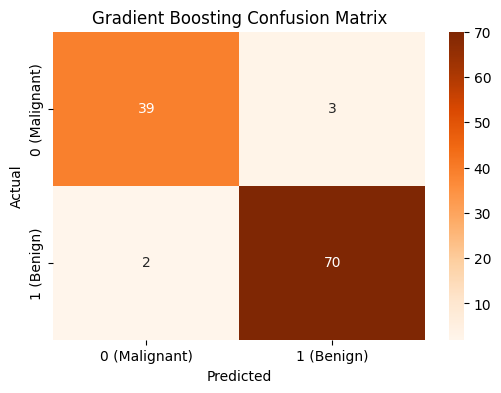

In [17]:
# Gradient Boosting Confusion Matrix 
gb_cm = confusion_matrix(y_test, gb_y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(gb_cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['0 (Malignant)', '1 (Benign)'], 
            yticklabels=['0 (Malignant)', '1 (Benign)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

3 malignant cases were missed and 2 benign cases were incorrectly flagged, the exact same error pattern as Random Forest. Both ensemble methods struggled slightly more with malignant cases compared to logistic regression.

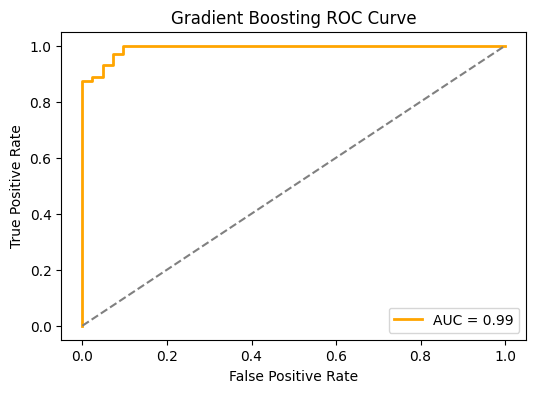

In [18]:
# Gradient Boosting ROC Curve

# get probabilities for the positive class (class 1)
gb_y_prob = grad_boost_grid_search.predict_proba(X_test)[:, 1]

fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_y_prob)
roc_auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(6, 4))
plt.plot(fpr_gb, tpr_gb, color='orange', lw=2, label=f"AUC = {roc_auc_gb:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")
plt.legend(loc="lower right")
plt.show()

An AUC of 0.99 matches Random Forest, both sitting just below logistic regression's perfect score.

## Support Vector Machines (SVM)

In [19]:
# Support Vector Machines (SVM)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', svm.SVC(
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        random_state=42
    ))
])

svm_param_grid = {
    'classifier__C' : [0.01, 0.1, 1, 2, 5, 10, 50, 100],
    'classifier__gamma' : ['scale', 'auto', 0.001, 0.01, 0.1, 1, 5]
}

svm_grid_search = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='recall_macro',
    n_jobs=-1
)

svm_grid_search.fit(X_train, y_train)

print(f"_____________________ SVM Best Hyperparameters _____________________")
print(f"Best C: {svm_grid_search.best_params_['classifier__C']}")
print(f"Best Gamma for RBF: {svm_grid_search.best_params_['classifier__gamma']}")

print(f"_____________________ SVM Model Preformance _____________________")
svm_y_pred = svm_grid_search.predict(X_test)
print(classification_report(y_test, svm_y_pred))
print(f"Best CV Recall Score (from GridSearch): {svm_grid_search.best_score_:.4f}")

_____________________ SVM Best Hyperparameters _____________________
Best C: 5
Best Gamma for RBF: 0.01
_____________________ SVM Model Preformance _____________________
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114

Best CV Recall Score (from GridSearch): 0.9800


SVM achieved 96% accuracy with a malignant recall of 0.98, matching logistic regression as the best performing model for catching malignant cases. The CV recall of 0.9800 was the highest of all four models, though it comes with slightly lower precision on malignant cases at 0.91.

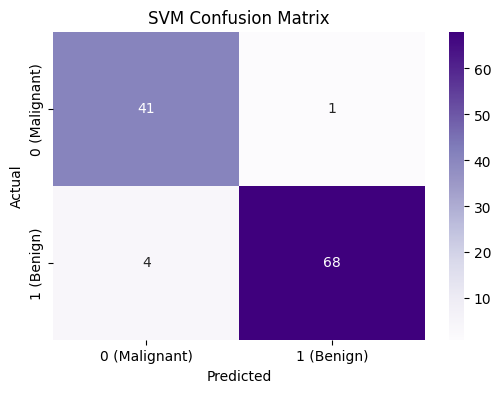

In [20]:
# SVM Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['0 (Malignant)', '1 (Benign)'], 
            yticklabels=['0 (Malignant)', '1 (Benign)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

Like logistic regression, SVM only missed 1 malignant case. However it flagged 4 benign cases as malignant compared to logistic regression's 3, meaning it is slightly more aggressive in its malignant predictions.

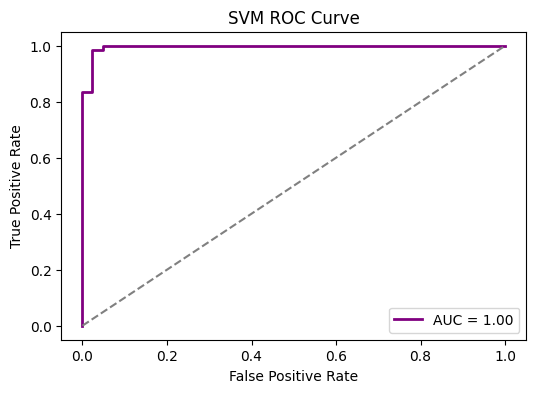

In [21]:
# SVM ROC Curve

# get probabilities for the positive class
svm_y_prob = svm_grid_search.predict_proba(X_test)[:, 1]

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_y_prob)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(6, 4))
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f"AUC = {roc_auc_svm:.2f}")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend(loc="lower right")
plt.show()

An AUC of 1.00 matches logistic regression, confirming that both models have near perfect class separability on this dataset.

# Final Analysis and Results

---

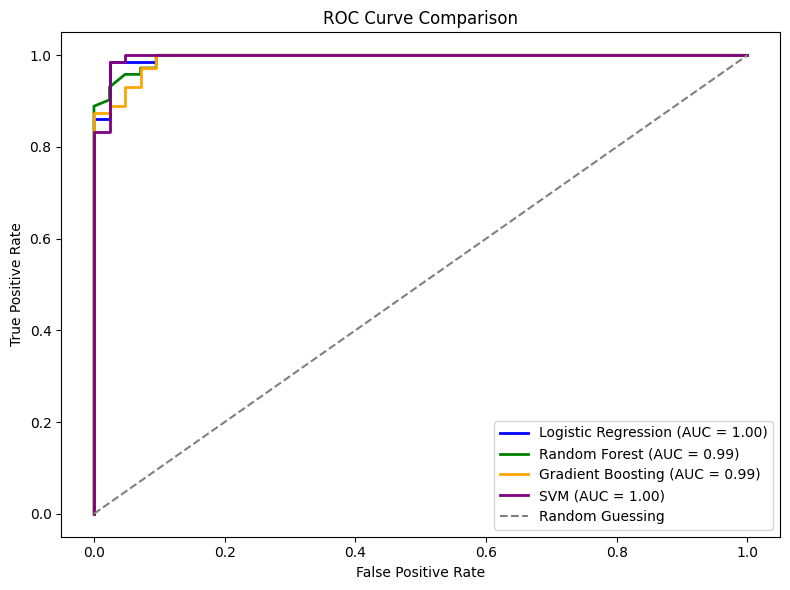

In [22]:
# one big ROC curve plot comparing ROC curves of all 4 models

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, color='blue', lw=2, label=f"Logistic Regression (AUC = {roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.plot(fpr_gb, tpr_gb, color='orange', lw=2, label=f"Gradient Boosting (AUC = {roc_auc_gb:.2f})")
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f"SVM (AUC = {roc_auc_svm:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guessing')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

All four models perform exceptionally well with AUC scores between 0.99 and 1.00, confirming strong class separability across the board. Logistic regression and SVM both achieved a perfect AUC of 1.00, while Random Forest and Gradient Boosting came in just behind at 0.99. The curves for all models hug the top left corner closely, indicating high true positive rates at very low false positive rates.

| Model | Accuracy | Malignant Recall | Malignant F1 | Macro F1 | Best CV Recall |
|-------|----------|-----------------|--------------|----------|----------------|
| Logistic Regression | 96% | 0.98 | 0.95 | 0.96 | 0.9748 |
| Random Forest | 96% | 0.93 | 0.94 | 0.95 | 0.9607 |
| Gradient Boosting | 96% | 0.93 | 0.94 | 0.95 | 0.9724 |
| SVM | 96% | 0.98 | 0.94 | 0.95 | 0.9800 |

All four models achieved 96% accuracy on the test set, so accuracy alone is not enough to differentiate them. Since we prioritized recall for malignant cases (class 0) as our primary metric, the results narrow down pretty clearly.

Logistic Regression and SVM both achieved the highest malignant recall at 0.98, meaning they only missed 1 malignant case out of 42 in the test set. Random Forest and Gradient Boosting both sat at 0.93, missing a few more malignant cases.

We selected Logistic Regression as our final model. It matched SVM on malignant recall, had the highest macro F1, and is the most interpretable of the four which matters in a clinical context where understanding why a prediction was made is just as important as the prediction itself.

In [23]:
# save the model as a pickle file

with open('../models/log_reg_breast_cancer.pkl', 'wb') as f:
    pickle.dump(log_reg_grid_search.best_estimator_, f)

print("Model saved as log_reg_breast_cancer.pkl")

Model saved as log_reg_breast_cancer.pkl
